# 🚢 Titanic Dataset Data Preprocessing Exercises XP


## Imports & chargement du dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Configuration affichage
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

# Chargement du dataset
df = pd.read_csv('train.csv')

print(f"Shape initiale : {df.shape}")
df.head()


Shape initiale : (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## Exercise 1: Duplicate Detection and Removal

**Objectif :** Identifier et supprimer les lignes dupliquées.


In [6]:
# 1. Nombre de lignes avant suppression
rows_before = len(df)
print(f"Nombre de lignes avant : {rows_before}")

# 2. Identifier les doublons (toutes colonnes confondues)
duplicates = df.duplicated()
print(f"Nombre de doublons détectés : {duplicates.sum()}")

# Afficher les doublons s'il y en a
if duplicates.sum() > 0:
    print(df[duplicates])

# 3. Supprimer les doublons
df = df.drop_duplicates()

# 4. Vérification
rows_after = len(df)
print(f"Nombre de lignes après : {rows_after}")
print(f"Lignes supprimées : {rows_before - rows_after}")


Nombre de lignes avant : 891
Nombre de doublons détectés : 0
Nombre de lignes après : 891
Lignes supprimées : 0


---
## Exercise 2: Handling Missing Values

**Objectif :** Identifier les colonnes avec des valeurs manquantes et appliquer des stratégies adaptées.


In [7]:
# 1. Identifier les valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing'] > 0])


          Missing  Percentage (%)
Age           177       19.865320
Cabin         687       77.104377
Embarked        2        0.224467


In [16]:
# 2. Stratégie par colonne

# Age (~20% manquant) imputation par la médiane (robuste aux outliers)
imputer_median = SimpleImputer(strategy='median')
df['Age'] = imputer_median.fit_transform(df[['Age']])
print(f"Age, valeurs manquantes restantes : {df['Age'].isnull().sum()}")

# Embarked (~2 valeurs manquantes) remplacement par le mode (valeur la plus fréquente)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(f"Embarked, valeurs manquantes restantes : {df['Embarked'].isnull().sum()}")

# Cabin (>70% manquant) colonne trop lacunaire, on la supprime
df.drop(columns=['Cabin'], inplace=True, errors='ignore')
print("Cabin, colonne supprimée.")

# Vérification finale
print(f"\nValeurs manquantes restantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])


Age, valeurs manquantes restantes : 0
Embarked, valeurs manquantes restantes : 0
Cabin, colonne supprimée.

Valeurs manquantes restantes :
Series([], dtype: int64)



## Exercise 3: Feature Engineering

**Objectif :** Créer de nouvelles features pertinentes et encoder les variables catégorielles.


In [17]:
# 1. Family Size = SibSp + Parch + 1 (le passager lui-même)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print("FamilySize créée.")
print(df['FamilySize'].value_counts())


FamilySize créée.
FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64


In [18]:
# 2. IsAlone : 1 si le passager voyage seul, 0 sinon
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print("IsAlone créée.")
print(df['IsAlone'].value_counts())


IsAlone créée.
IsAlone
1    537
0    354
Name: count, dtype: int64


In [19]:
# 3. Extraction du titre depuis la colonne Name
# Format : "Nom, Titre. Prénom"
df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.', expand=False).str.strip()
print("Titres extraits :")
print(df['Title'].value_counts())


Titres extraits :
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [20]:
# 4. Regroupement des titres rares → 'Rare'
rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Regroupements sémantiques supplémentaires
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
print("Titres après regroupement :")
print(df['Title'].value_counts())


Titres après regroupement :
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [21]:
# 5. Encodage du titre via Label Encoding (sera affiné en Ex6)
le = LabelEncoder()
df['Title_encoded'] = le.fit_transform(df['Title'])
print("Title encodé.")
print(df[['Title', 'Title_encoded']].drop_duplicates().sort_values('Title_encoded'))


Title encodé.
     Title  Title_encoded
7   Master              0
2     Miss              1
0       Mr              2
1      Mrs              3
30    Rare              4


---
## Exercise 4: Outlier Detection and Handling

**Objectif :** Détecter et traiter les outliers dans `Fare` et `Age`.


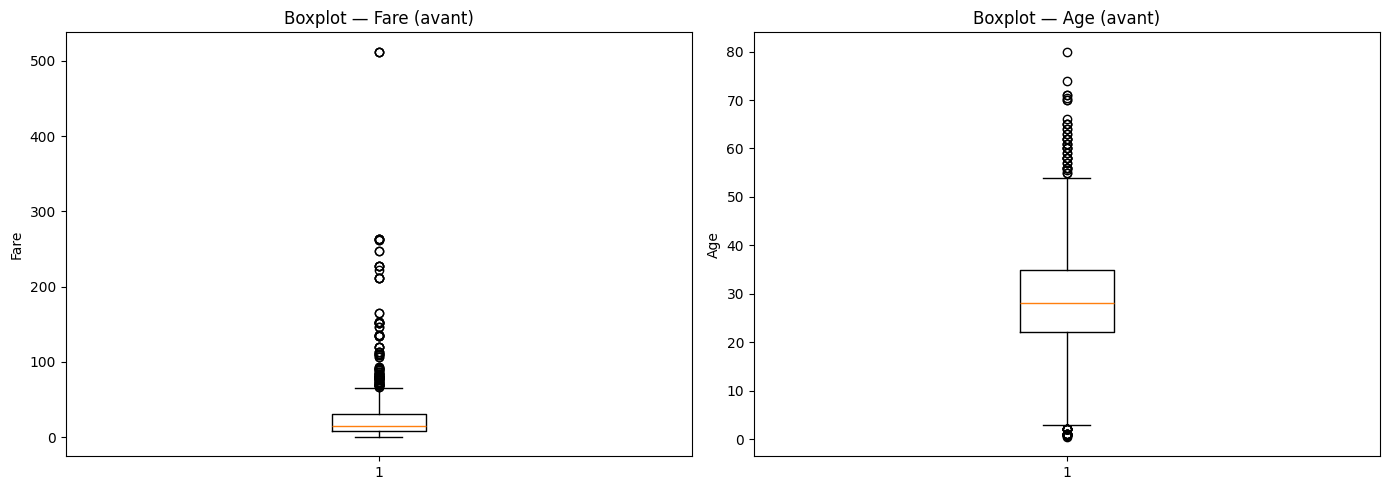

In [22]:
# 1. Visualisation des distributions (avant traitement)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['Fare'].dropna())
axes[0].set_title('Boxplot — Fare (avant)')
axes[0].set_ylabel('Fare')

axes[1].boxplot(df['Age'].dropna())
axes[1].set_title('Boxplot — Age (avant)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()


In [23]:
# 2. Détection via IQR pour Fare
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_fare = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print(f"Outliers Fare détectés : {len(outliers_fare)}")
print(f"  Borne inférieure : {lower:.2f} | Borne supérieure : {upper:.2f}")


Outliers Fare détectés : 116
  Borne inférieure : -26.72 | Borne supérieure : 65.63


In [24]:
# 3. Traitement Fare → Capping au quantile 0.98 (pour conserver la distribution)
cap_98 = df['Fare'].quantile(0.98)
print(f"Quantile 0.98 Fare : {cap_98:.2f}")
df['Fare'] = df['Fare'].clip(upper=cap_98)
print(f"Fare max après capping : {df['Fare'].max():.2f}")


Quantile 0.98 Fare : 211.34
Fare max après capping : 211.34


In [25]:
# 4. Détection via Z-score pour Age
z_scores = np.abs(stats.zscore(df['Age'].dropna()))
print(f"Outliers Age (|z| > 3) : {(z_scores > 3).sum()}")

# Traitement Age → Capping au quantile 0.98
cap_age = df['Age'].quantile(0.98)
df['Age'] = df['Age'].clip(upper=cap_age)
print(f"Age max après capping : {df['Age'].max():.1f}")


Outliers Age (|z| > 3) : 7
Age max après capping : 62.0


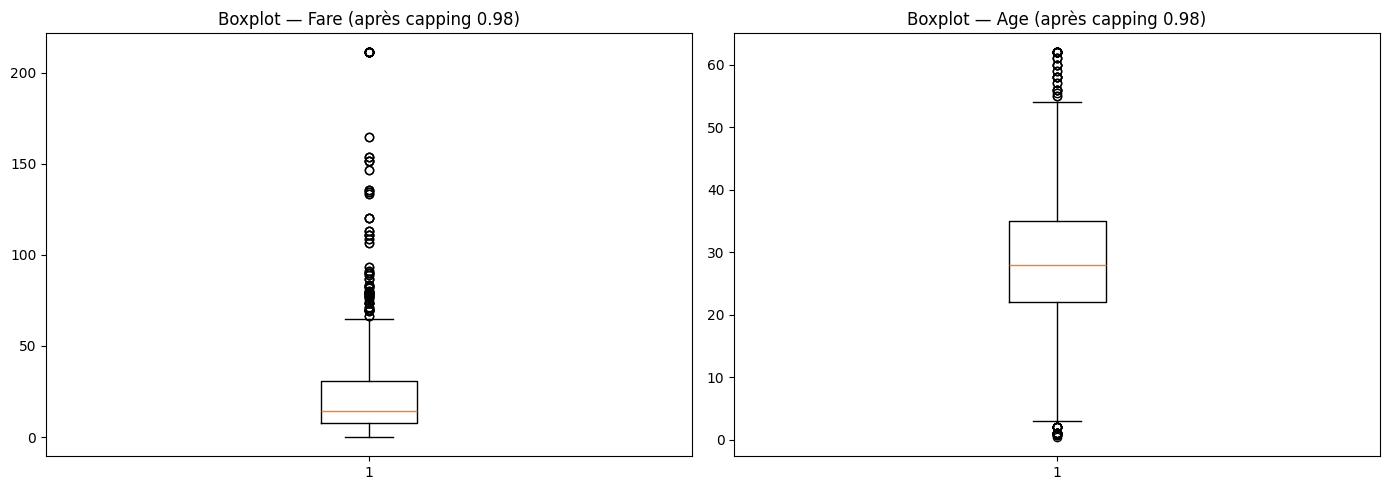

In [26]:
# 5. Visualisation après traitement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['Fare'])
axes[0].set_title('Boxplot — Fare (après capping 0.98)')

axes[1].boxplot(df['Age'])
axes[1].set_title('Boxplot — Age (après capping 0.98)')

plt.tight_layout()
plt.show()


---
## Exercise 5: Data Standardization and Normalization

**Objectif :** Mettre à l'échelle les features numériques après traitement des outliers.


In [27]:
# StandardScaler → features approximativement normales : Age, FamilySize
standard_cols = ['Age', 'FamilySize']
scaler_std = StandardScaler()
df[standard_cols] = scaler_std.fit_transform(df[standard_cols])

print("StandardScaler appliqué sur :", standard_cols)
print(df[standard_cols].describe().round(3))


StandardScaler appliqué sur : ['Age', 'FamilySize']
           Age  FamilySize
count  891.000     891.000
mean     0.000      -0.000
std      1.001       1.001
min     -2.268      -0.561
25%     -0.571      -0.561
50%     -0.099      -0.561
75%      0.452       0.059
max      2.575       5.640


In [28]:
# MinMaxScaler → feature skewed/bornée : Fare
minmax_cols = ['Fare']
scaler_mm = MinMaxScaler()
df[minmax_cols] = scaler_mm.fit_transform(df[minmax_cols])

print("MinMaxScaler appliqué sur :", minmax_cols)
print(df[minmax_cols].describe().round(3))


MinMaxScaler appliqué sur : ['Fare']
          Fare
count  891.000
mean     0.145
std      0.189
min      0.000
25%      0.037
50%      0.068
75%      0.147
max      1.000


---
## Exercise 6: Feature Encoding

**Objectif :** Finaliser l'encodage des variables catégorielles restantes.


In [30]:
# Identifier les colonnes catégorielles restantes
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Colonnes catégorielles restantes :", cat_cols)


Colonnes catégorielles restantes : ['Name', 'Sex', 'Ticket', 'Embarked', 'Title']


/tmp/ipykernel_8690/636393983.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [31]:
# One-Hot Encoding pour Sex et Embarked (variables nominales)
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print("One-Hot Encoding appliqué sur : Sex, Embarked")
print("Nouvelles colonnes :", [c for c in df.columns if 'Sex' in c or 'Embarked' in c])


One-Hot Encoding appliqué sur : Sex, Embarked
Nouvelles colonnes : ['Sex_male', 'Embarked_Q', 'Embarked_S']


In [32]:
# Title : déjà encodé en Label Encoding (Title_encoded, Ex3)
# On supprime la colonne texte originale
df.drop(columns=['Title'], inplace=True)
print("Colonne 'Title' (texte) supprimée — 'Title_encoded' conservé.")

# Suppression des colonnes inutiles pour la modélisation
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)
print("Colonnes non-informatives supprimées : Name, Ticket, PassengerId")

print(f"\nShape finale : {df.shape}")
df.head()


Colonne 'Title' (texte) supprimée — 'Title_encoded' conservé.
Colonnes non-informatives supprimées : Name, Ticket, PassengerId

Shape finale : (891, 12)


,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Title_encoded,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.570988,1,0,0.034305,0.059160,0,2,True,False,True
1,1,1,0.687580,1,0,0.337296,0.059160,0,3,False,False,False
2,1,3,-0.256346,0,0,0.037499,-0.560975,1,1,False,False,True
3,1,1,0.451599,1,0,0.251257,0.059160,0,3,False,False,True
4,0,3,0.451599,0,0,0.038091,-0.560975,1,2,True,False,True


---
## Exercise 7: Data Transformation for Age Feature

**Objectif :** Créer des groupes d'âge et les encoder en one-hot.


In [33]:
# Recharger l'Age original pour créer les bins (simulation pipeline propre)
df_raw = pd.read_csv('train.csv')
df_raw['Age'] = df_raw['Age'].fillna(df_raw['Age'].median())

# Définir les bins et labels
bins = [0, 12, 18, 60, 100]
labels = ['child', 'teen', 'adult', 'senior']

df_raw['AgeGroup'] = pd.cut(df_raw['Age'], bins=bins, labels=labels)
print("Distribution des groupes d'âge :")
print(df_raw['AgeGroup'].value_counts().sort_index())


Distribution des groupes d'âge :
AgeGroup
child      69
teen       70
adult     730
senior     22
Name: count, dtype: int64


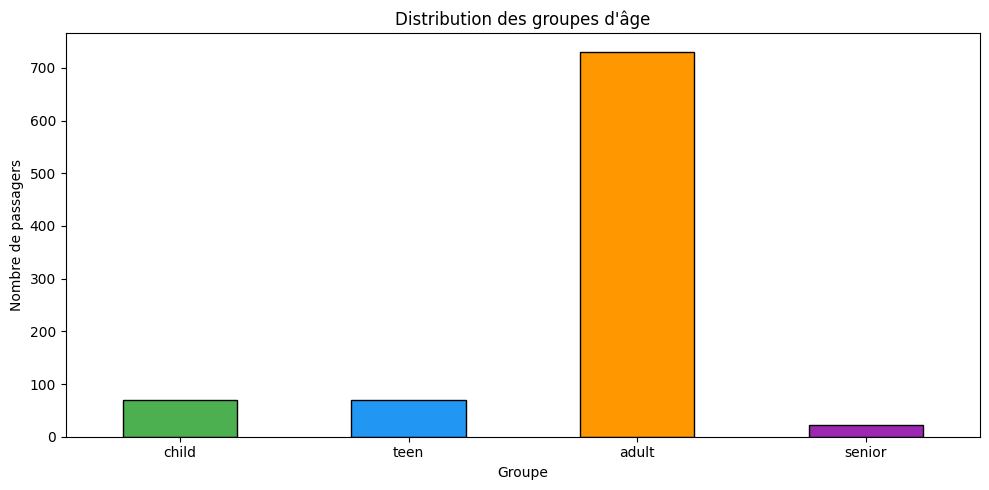

In [34]:
# Visualisation
df_raw['AgeGroup'].value_counts().sort_index().plot(
    kind='bar', color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'],
    edgecolor='black', rot=0
)
plt.title("Distribution des groupes d'âge")
plt.xlabel("Groupe")
plt.ylabel("Nombre de passagers")
plt.tight_layout()
plt.show()


In [35]:
# One-Hot Encoding des groupes d'âge
age_dummies = pd.get_dummies(df_raw['AgeGroup'], prefix='Age')
print("Colonnes générées :")
print(age_dummies.head())

# Fusionner dans le dataframe principal (df déjà preprocessé)
df = pd.concat([df.reset_index(drop=True), age_dummies.reset_index(drop=True)], axis=1)
print(f"\nShape après ajout des AgeGroups : {df.shape}")


Colonnes générées :
   Age_child  Age_teen  Age_adult  Age_senior
0      False     False       True       False
1      False     False       True       False
2      False     False       True       False
3      False     False       True       False
4      False     False       True       False

Shape après ajout des AgeGroups : (891, 16)
